<a href="https://colab.research.google.com/github/yuniecorn-dev/esaa_assignment/blob/main/ESAA_YB_WEEK5_study_0403.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#4. 분류
(p.181 ~ 210)

##4.1 분류(Classification)의 개요
- 지도 학습: 레이블(Label), 즉 명시적인 정답이 있는 데이터가 주어진 상태에서 학습하는 머신러닝 방식
- 분류
  - 지도학습의 대표 유형
  - 학습 데이터로 주어진 데이터의 피처와 레이블값(결정 값, 클래스 값)을
  - 머신러닝 알고리즘으로 학습해 모델을 생성하고,
  - 이렇게 생성된 모델에 새로운 데이터 값이 주어졌을 때
  - 미지의 레이블 값을 예측하는 것

=> 기존 데이터가 어떤 레이블에 속하는지 패턴을 알고리즘으로 인지한 뒤에 새롭게 관측된 데이터에 대한 레이블을 판별


[분류를 구현하는 다양한 머신러닝 알고리즘]
- 베이즈(Bayes) 통계와 생성 모델에 기반한 나이브 베이즈(Naive Bayes)
- 독립변수와 종속변수의 선형 관계성에 기반한 로지스틱 회귀(Logistic Regression)
- 데이터 균일도에 따른 규칙 기반의 결정 트리(Decision Tree)
- 개별 클래스 간의 최대 분류 마진을 효과적으로 찾아주는 서포트 벡터 머신(Support Vector Machine)
- 근접 거리를 기준으로 하는 최소 근접(Nearest Neighbor) 알고리즘
- 심층 연결 기반의 신경망(Neural Network)
- 서로 다른(또는 같은) 머신러닝 알고리즘을 결합한 앙상블(Ensemble)
<br>

[앙상블 방법(Ensemble Method)]
- 배깅(Bagging)과 부스팅(Boosting)으로 나뉨.
- 배깅 > 랜덤 포레스트(Random Forest) 애용
- Boosting 방식으로 발전하고 있음.
  - Gradient Boosting: 수행시간 긺.
  - XgBoost(eXtra Gradient Boost), LightGBM: 수행시간 단축시킨 알고리즘
- 보통 서로 같은 알고리즘을 결합함.
- 기본 알고리즘: 결정 트리
  - 쉽고 유연하게 적용 가능
  - 데이터의 스케일링, 정규화 등 사전 가공의 영향 적음.
  - 과적합 발생 유의 필요

##4.2 결정 트리
- 데이터에 있는 규칙을 학습을 통해 자동으로 찾아내 트리(Tree) 기반의 분류 규칙을 만드는 것.
- 데이터의 어떤 기준으로 규칙을 만들어야 가장 효율적인 분류가 될 것인가
- 트리의 깊이(depth)가 깊어질수록 과적합으로 이어지기 쉽고, 예측 성능이 저하될 가능성이 높음.
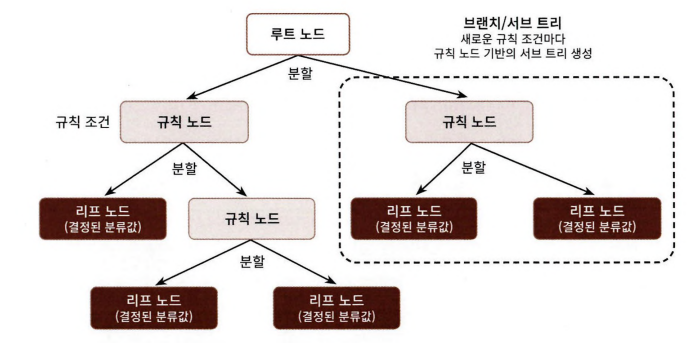

### 규칙 조건 기준
- 가능한 한 적은 결정 노드로 높은 예측 정확도를 가지려면
- 데이터를 분류할 때 최대한 많은 데이터 세트가 해당 분류에 속할 수 있도록
- 결정 노드의 규칙이 정해져야 함.

=> 어떻게 트리를 분할(Split)할 것인가 (균일 is good)

<br>

- 결정 노드: 정보 균일도가 높은 데이터 세트를 먼저 선택할 수 있도록 규칙 조건 만듦.
- 예시: (노랑&동그라미) 그리고 (빨강, 파랑)&(네모, 세모)이 있다면 가장 첫번째로 만들어져야 하는 규칙 조건은 if 색깔 == '노란색'

###정보 이득(Information Gain)
1) 지수
- 정보 이득은 엔트로피라는 개념 기반
  - 엔트로피: 주어진 데이터 집합의 혼잡도
  - 서로 다른 값이 섞여 있으면 엔트로피가 높고, 같은 값이 섞여 있으면 엔트로피가 낮음.
- 정보 이득 지수 = (1 - 엔트로피 지수)
  - 결정 트리는 이 지수로 분할 기준을 정함.
  - 정보 이득이 높은 속성을 기준으로 분할

2) 지니 계수
- 경제학에서 불평등 지수를 나타낼 때 사용하는 계수
- 0이 가장 평등하고 1로 갈수록 불평등함.
- 지니 계수가 낮을수록 데이터 균일도가 높은 것으로 해석 -> 지니 계수가 낮은 속성을 기준으로 분할

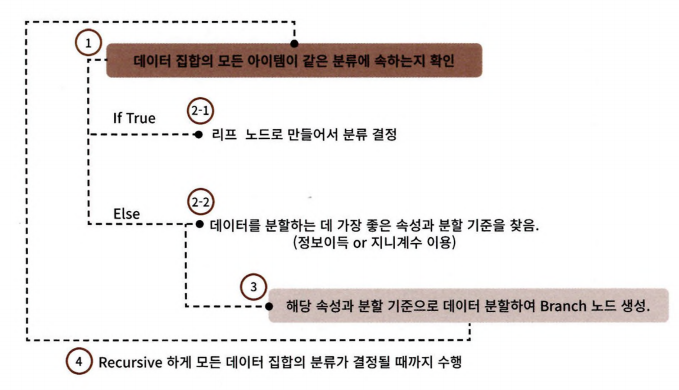

###결정 트리 모델의 특징
- 알고리즘이 쉽고 직관적
- 전처리 작업 필요X (각 피처의 스케일링과 정규화 등)
- 과적합으로 정확도가 떨어짐. 이를 극복하기 위해 트리의 크기를 사전에 제한하는 튜닝 필요.

###결정 트리 파라미터
- 분류: DecisionTreeClassifier 클래스
- 회귀: DecisionTreeRegressor 클래스
- CART 알고리즘

<br>

[결정 트리 파라미터]
| 파라미터 명 | 설명 |
| :--- | :--- |
| **min_samples_split** | <ul><li>노드를 분할하기 위한 최소한의 샘플 데이터 수로 과적합을 제어하는 데 사용됨.</li><li>디폴트는 2이고 작게 설정할수록 분할되는 노드가 많아져서 과적합 가능성 증가</li></ul> |
| **min_samples_leaf** | <ul><li>분할이 될 경우 왼쪽과 오른쪽의 브랜치 노드에서 가져야 할 최소한의 샘플 데이터 수</li><li>큰 값으로 설정될수록, 분할될 경우 왼쪽과 오른쪽의 브랜치 노드에서 가져야 할 최소한의 샘플 데이터 수 조건을 만족시키기가 어려우므로 노드 분할을 상대적으로 덜 수행함.</li><li>`min_samples_split`과 유사하게 과적합 제어 용도. 그러나 비대칭적(imbalanced) 데이터의 경우 특정 클래스의 데이터가 극도로 작을 수 있으므로 이 경우는 작게 설정 필요.</li></ul> |
| **max_features** | <ul><li>최적의 분할을 위해 고려할 최대 피처 개수. 디폴트는 None으로 데이터 세트의 모든 피처를 사용해 분할 수행.</li><li>int 형으로 지정하면 대상 피처의 개수, float 형으로 지정하면 전체 피처 중 대상 피처의 퍼센트임</li><li>'sqrt'는 전체 피처 중 sqrt(전체 피처 개수), 즉 $\sqrt{\text{전체 피처 개수}}$ 만큼 선정</li><li>'auto'로 지정하면 sqrt와 동일</li><li>'log'는 전체 피처 중 log2(전체 피처 개수) 선정</li><li>'None'은 전체 피처 선정</li></ul> |
| **max_depth** | <ul><li>트리의 최대 깊이를 규정.</li><li>디폴트는 None. None으로 설정하면 완벽하게 클래스 결정 값이 될 때까지 깊이를 계속 키우며 분할하거나 노드가 가지는 데이터 개수가 `min_samples_split`보다 작아질 때까지 계속 깊이를 증가시킴.</li><li>깊이가 깊어지면 `min_samples_split` 설정대로 최대 분할하여 과적합할 수 있으므로 적절한 값으로 제어 필요.</li></ul> |
| **max_leaf_nodes** | <ul><li>말단 노드(Leaf)의 최대 개수</li></ul> |

###결정 트리 모델의 시각화
- Graphviz 패키지 사용
- 그래프 기반의 dot 파일. 기술된 다양한 이미지를 쉽게 시각화할 수 있는 패키지
- export_graphviz()
  - 학습이 완료된 Estimator, 피처의 이름 리스트, 레이블 이름 리스트를 입력하면 학습된 결정 트리 규칙을 실제 트리 형태로 시각화해 보여줌.

In [ ]:
!pip install graphviz

In [ ]:
# Graphviz를 이용해 붓꽃 데이터 세트에 결정 트리를 적용할 때 어떻게 서브 트리가 구성되고 만들어지는지 시각화

from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# DecisionTree Classifier 생성
dt_clf = DecisionTreeClassifier(random_state=156)

# 붓꽃 데이터를 로딩하고, 학습과 테스트 데이터 세트로 분리
iris_data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target,
                                                    test_size=0.2, random_state=11)

# DecisionTreeClassifier 학습
dt_clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=156)

In [ ]:
from sklearn.tree import export_graphviz

# export_graphviz()의 호출 결과로 out_file로 지정된 tree.dot 파일을 생성함.
export_graphviz(dt_clf, out_file="tree.dot", class_names=iris_data.target_names,
                feature_names = iris_data.feature_names, impurity=True, filled=True)

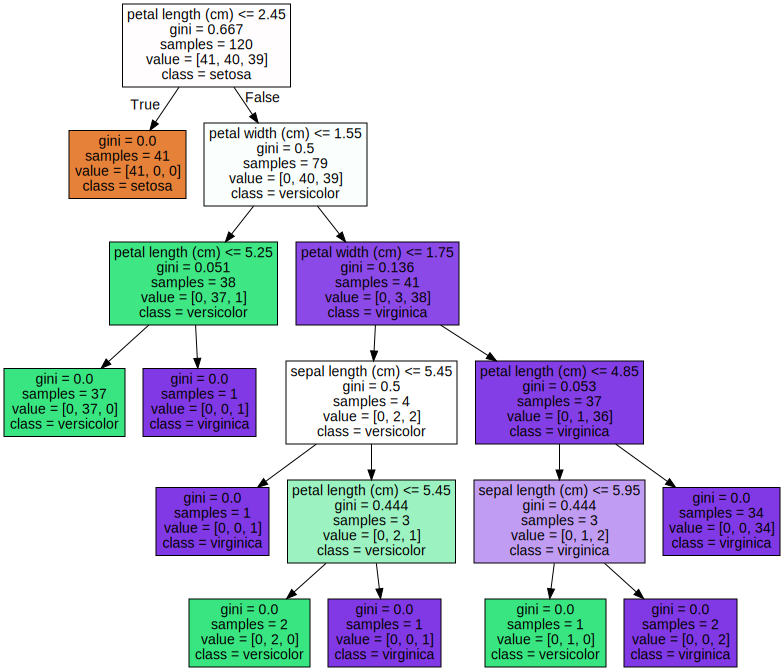

In [ ]:
import graphviz
# 위에서 생성된 tree.dot 파일을 Graphviz가 읽어서 주피터 노트북상에서 시각화
with open("tree.dot") as f:
  dot_graph = f.read()
graphviz.Source(dot_graph)

- 각 규칙에 따라 트리의 브랜치(branch) 노드와 말단 리프(Leaf) 노드가 어떻게 구성되는지 한눈에 알 수 있게 시각화돼 있음.
- 리프 노드: 더이상 자식 노드가 없는 노드
  - 최종 클래스 값이 결정되는 노드
- 브랜치 노드: 자식 노드가 있는 노드
  - 자식 노드를 만들기 위한 분할 규칙 조건을 가짐.

<br>

####지표의 의미
- petal length(cm) <= 2.45와 같이 피처의 조건이 있는 것은 자식 노드를 만들기 위한 규칙 조건. 이 조건이 없으면 리프 노드
- gini: 다음의 value=[]로 주어진 데이터 분포에서의 지니 계수
- samples: 현 규칙에 해당하는 데이터 건수
- value = []: 클래스 값 기반의 데이터 건수
  - 붓꽃 데이터 세트는 클래스 값으로 0,1,2를 가지고 있으며, 0:Setosa, 1:Versicolor, 2:Virginica 품종을 가리킴. 만일 Value = [41,40,39]라면 클래스 값의 순서로 Setosa 41개, Versicolor 40개, Virginica 39개로 데이터가 구성되어 있다는 의미.
- class = sesota: 하위 노드를 가질 경우에 sesota의 개수가 41개로 제일 많다.

<br>

####색깔의 의미
- 노드의 색깔: 붓꽃 데이터의 레이블 값을 의미
- 주황색은 0:Setosa, 초록색은 1:Versicolor, 보라색은 2:Virginica
- 색깔이 짙어질수록 지니 계수가 낮고 해당 레이블에 속하는 샘플 데이터가 많다는 의미

<br>

####최대 트리 깊이 제어
- max_depth = 숫자

<br>

####하이퍼 파라미터 변경에 따른 규칙 트리의 변화
1) min_samples_split
- 자식 규칙 노드를 분할해 만들기 위한 최소한의 샘플 데이터 개수
- 예: min_samp!es_splits=4로 설정한 경우의 결정 트리
  - 맨 아래 리프 노드 중 사선 박스로 표시된 노드를 보면 샘플이 3개인데, 이 노드 안에 value가 [0, 2, 1]과 [0, 1, 2]로 서로 상이한 클래스 값이 있어도 더 이상 분할하지 않고 리프 노드가 됨. min_samples_splits=4, 즉 자식 노드로 분할하려면 최소한 샘플 개수가 4개는 필요한데, 3개밖에 없으므로 더 이상 자식 규칙 노드를 위한 분할을 하지 않고 리프 노드가 됨.

2) min_samples_leaf
- 분할될 경우 왼쪽과 오른쪽 자식 노드 각각이 가지게 될 최소 데이터 건수를 지정
- 어떤 노드가 분할할 경우, 왼쪽과 오른쪽 자식 노드 중에 하나라도 min_samples_leaf로 지정된 최소 데이터 건수보다 더 작은 샘플 데이터 건수를 갖게 된다면, 해당 노드는 더 이상 분할하지 않고 리프 노드가 됨.


####features_importances
- ndarray 형태로 값을 반환. 피처 순서대로 값이 할당
- 피처가 트리 분할 시 정보 이득이나 지니 계수를 얼마나 효율적으로 잘 개선시켰는지를 정규화된 값으로 표현한 것.
- 값이 높을수록 해당 피처의 중요도가 높다.

Feature importances:
[0.025 0.    0.555 0.42 ]
sepal length (cm) : 0.025
sepal width (cm) : 0.000
petal length (cm) : 0.555
petal width (cm) : 0.420


<Axes: >

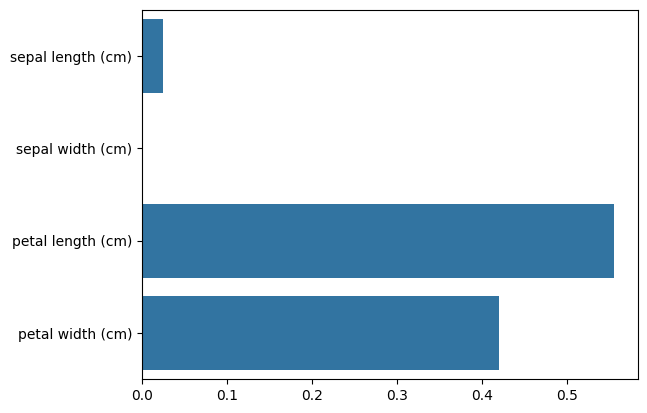

In [ ]:
import seaborn as sns
import numpy as np
%matplotlib inline

# feature importance 추출
print("Feature importances:\n{0}".format(np.round(dt_clf.feature_importances_,3)))

# feature별 importance 매핑
for name, value in zip(iris_data.feature_names, dt_clf.feature_importances_):
  print('{0} : {1:.3f}'.format(name, value))

# feature importance를 column 별로 시각화하기
sns.barplot(x=dt_clf.feature_importances_, y=iris_data.feature_names)

petal length가 가장 피처 중요도가 높음.

###결정 트리 과적합(Overfitting)
- 결정 트리가 어떻게 학습 데이터를 분할해 예측을 수행하는지
- 이로 인한 과적합 문제를 시각화해 알아보자

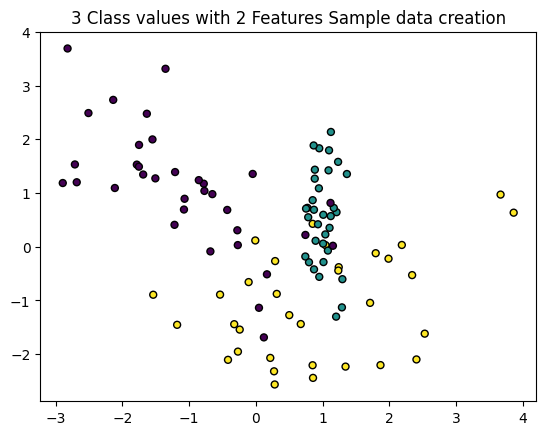

In [6]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
%matplotlib inline

plt.title("3 Class values with 2 Features Sample data creation")

# 2차원 시각화를 위해서 피처는 2개, 클래스는 3가지 유형의 분류 샘플 데이터 생성.
X_features, y_labels = make_classification(n_features=2, n_redundant=0, n_informative=2,
                                           n_classes=3, n_clusters_per_class=1,random_state=0)

# 그래프 형태로 2개의 피처로 2차원 좌표 시각화, 각 클래스 값은 다른 색깔로 표시됨.
plt.scatter(X_features[:,0], X_features[:,1], marker='o', c=y_labels, s=25, edgecolor='k')

####첫 번째 모델

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def visualize_boundary(model, X, y):
    # 범위 설정
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # mesh grid 생성
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.01),
        np.arange(y_min, y_max, 0.01)
    )

    # 모델 예측
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # 색상 설정
    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF', '#AAFFAA'])
    cmap_bold = ListedColormap(['#FF0000', '#0000FF', '#00FF00'])

    # 시각화
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

    plt.scatter(
        X[:, 0], X[:, 1],
        c=y,
        cmap=cmap_bold,
        s=25,
        edgecolor='k'
    )

    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

    plt.title("Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

    plt.show()

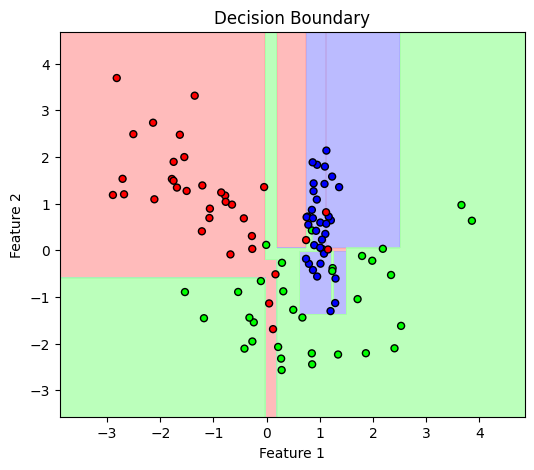

In [8]:
from sklearn.tree import DecisionTreeClassifier

# 특정한 트리 생성 제약 없는 결정 트리의 학습과 결정 경계 시각화.
dt_clf = DecisionTreeClassifier(random_state=156).fit(X_features, y_labels)
visualize_boundary(dt_clf, X_features, y_labels)

일부 이상치(Outlier) 데이터까지 분류하기 위해 분할이 자주 일어나서 결정 기준 경계가 매우 많아짐.

####두 번째 모델

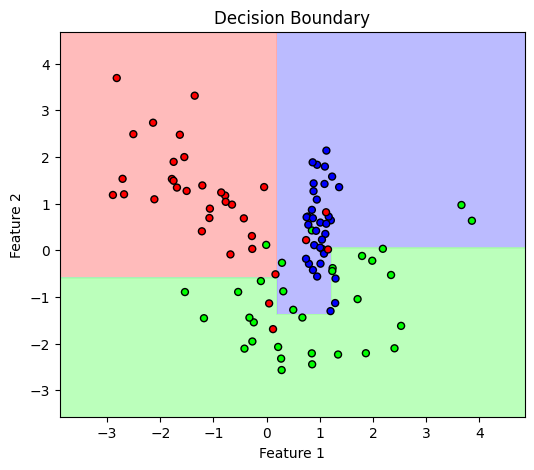

In [7]:
# min_samples_leaf=6으로 트리 생성 조건을 제약한 결정 경계 시각화
dt_clf = DecisionTreeClassifier(min_samples_leaf=6, random_state=156).fit(X_features, y_labels)
visualize_boundary(dt_clf, X_features, y_labels)

결정 트리 모델의 예측 성능은 첫 번째 모델보다는 min_
samples_leaf=6으로 트리 생성 조건을 제약한 모델이 더 뛰어날 가능성이 높음.

<= 테스트 데이터 세트는 학습 데이터 세트와는 다른 데이터 세트인데, 학습 데이터에만 지나치게 최적화된 분류 기준은 오히려 테스트 데이터 세트에서 정확도를 떨어뜨림.

###결정 트리 실습 - 사용자 행동 인식 데이터 세트
- 데이터는 30명에게 스마트폰 센서를 장착한 뒤 사람의 동작과 관련된 여러 가지 피처를 수집한 데이터
- 수집된 피처 세트를 기반으로 결정 트리를 이용해 어떠한 동작인지 예측

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# features.txt 파일에는 피처 이름 index와 피처명이 공백으로 분리되어 있음. 이를 DataFrame으로 로드.
feature_name_df = pd.read_csv('features.txt', sep='\s+',
                              header=None, names=['column_index', 'column_name'])

# 피처명 index를 제거하고, 피처명만 리스트 객체로 생성한 뒤 샘플로 10개만 추출
feature_name = feature_name_df.iloc[:,1].values.tolist()
print('전체 피처명에서 10개만 추출:', feature_name[:10])

전체 피처명에서 10개만 추출: ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X']


In [ ]:
# 중복된 피처명이 얼마나 있는지 알아보기
feature_dup_df = feature_name_df.groupby('column_name').count()
print(feature_dup_df[feature_dup_df['column_index']>1].count())
feature_dup_df[feature_dup_df['column_index']>1].head()

column_index    42
dtype: int64


,column_index
column_name,
"fBodyAcc-bandsEnergy()-1,16",3
"fBodyAcc-bandsEnergy()-1,24",3
"fBodyAcc-bandsEnergy()-1,8",3
"fBodyAcc-bandsEnergy()-17,24",3
"fBodyAcc-bandsEnergy()-17,32",3


42개의 피처명이 중복됨.

In [ ]:
def get_new_feature_name_df(old_feature_name_df):
  feature_dup_df = pd.DataFrame(data=old_feature_name_df.groupby('column_name').cumcount(),
                                columns=['dup_cnt'])
  feature_dup_df = feature_dup_df.reset_index()
  new_feature_name_df = pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how='outer')
  new_feature_name_df['column_name'] = new_feature_name_df[['column_name',
                                                            'dup_cnt']].apply(lambda x : x[0]+'_'+str(x[1])
                                                              if x[1] > 0 else x[0], axis=1)
  new_feature_name_df = new_feature_name_df.drop(['index'], axis=1)
  return new_feature_name_df

In [ ]:
import pandas as pd

def get_human_dataset():

  # 각 데이터 파일은 공백으로 분리되어 있으므로 read_csv에서 공백 문자를 sep으로 할당.
  feature_names_df = pd.read_csv('features.txt', sep='\s+',
                                 header=None, names=['column_index', 'column_name'])

  # 중복된 피처명을 수정하는 get_new_feature_name_df()를 이용, 신규 피처명 DataFrame 생성.
  new_feature_name_df = get_new_feature_name_df(feature_name_df)

  # DataFrame에 피처명을 칼럼으로 부여하기 위해 리스트 객체로 다시 변환
  feature_name = new_feature_name_df.iloc[:,1].values.tolist()

  # 학습 피처 데이터세트와 테스트 피처 데이터를 DataFrame으로 로딩. 칼럼명은 feature_name 적용
  X_train = pd.read_csv('X_train.txt', sep='\s+', names=feature_name)
  X_test = pd.read_csv('X_test.txt', sep='\s+', names=feature_name)

  # 학습 레이블과 테스트 레이블 데이터를 DataFrame으로 로딩하고 칼럼명은 action으로 부여
  y_train = pd.read_csv('y_train.txt', sep='\s+', header=None, names=['action'])
  y_test = pd.read_csv('y_test.txt', sep='\s+', header=None, names=['action'])

  # 로드된 학습/테스트용 DataFrame을 모두 반환
  return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = get_human_dataset()

In [ ]:
print('## 학습 피처 데이터셋 info()')
print(X_train.info())

## 학습 피처 데이터셋 info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 561 entries, tBodyAcc-mean()-X to angle(Z,gravityMean)
dtypes: float64(561)
memory usage: 31.5 MB
None


- 학습 데이터 세트는 7352개의 레코드로 561개의 피처를 가짐.
- 피처가 전부 float 형의 숫자형이므로 별도의 카테고리 인코딩은 수행할 필요X

In [ ]:
# 1~6까지 분포 고름
print(y_train['action'].value_counts())

action
6    1407
5    1374
4    1286
1    1226
2    1073
3     986
Name: count, dtype: int64


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 예제 반복 시마다 동일한 예측 결과 도출을 위해 random_state 설정
dt_clf = DecisionTreeClassifier(random_state=156)
dt_clf.fit(X_train, y_train)
pred = dt_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred)
print('결정 트리 예측 정확도: {0:.4f}'.format(accuracy))

# DecisionTreeClassifier의 하이퍼 파라미터 추출
print('DecisionTreeClassifier 기본 하이퍼 파라미터:\n', dt_clf.get_params())

결정 트리 예측 정확도: 0.8548
DecisionTreeClassifier 기본 하이퍼 파라미터:
 {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 156, 'splitter': 'best'}


In [ ]:
# 결정 트리의 트리 깊이(Tree Depth)가 예측 정확도에 주는 영향
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [6,8,10,12,16,20,24],
    'min_samples_split': [16]
}


grid_cv = GridSearchCV(dt_clf, param_grid=params, scoring='accuracy', cv=5, verbose=1)
grid_cv.fit(X_train, y_train)
print('GridSearchCV 최고 평균 정확도 수치: {0:.4f}'.format(grid_cv.best_score_))
print('GridSearchCV 최적 하이퍼 파라미터:', grid_cv.best_params_)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
GridSearchCV 최고 평균 정확도 수치: 0.8549
GridSearchCV 최적 하이퍼 파라미터: {'max_depth': 8, 'min_samples_split': 16}


- max_depth = 8일때 5개의 폴드 세트의 최고 평균 정확도 결과가 약 85.49%로 도출됨.

In [ ]:
#  max_depth 값의 증가에 따라 예측 성능이 어떻게 변했는지 확인

# GridSearchCV 객체의 cv_results_ 속성을 DataFrame으로 생성.
cv_results_df = pd.DataFrame(grid_cv.cv_results_)

# max_depth 파라미터 값과 그때의 테스트 세트, 학습 데이터 세트의 정확도 수치 추출
cv_results_df[['param_max_depth', 'mean_test_score']]

,param_max_depth,mean_test_score
0,6,0.847662
1,8,0.854879
2,10,0.852705
3,12,0.845768
4,16,0.847127
5,20,0.848624
6,24,0.848624


In [ ]:
max_depths = [6, 8, 10, 12, 16, 20, 24]
# max_depth 값을 변화시키면서 그때마다 학습과 테스트 세트에서의 예측 성능 측정
for depth in max_depths:
  dt_clf = DecisionTreeClassifier(max_depth=depth, min_samples_split=16, random_state=156)
  dt_clf.fit(X_train, y_train)
  pred = dt_clf.predict(X_test)
  accuracy = accuracy_score(y_test, pred)
  print('max_depth = {0} 정확도: {1:.4f}'.format(depth, accuracy))

max_depth = 6 정확도: 0.8551
max_depth = 8 정확도: 0.8717
max_depth = 10 정확도: 0.8599
max_depth = 12 정확도: 0.8571
max_depth = 16 정확도: 0.8599
max_depth = 20 정확도: 0.8565
max_depth = 24 정확도: 0.8565


In [ ]:
params = {
    'max_depth': [8, 12, 16, 20],
    'min_samples_split': [16, 24],
}

grid_cv = GridSearchCV(dt_clf, param_grid=params, scoring='accuracy', cv=5, verbose=1)
grid_cv.fit(X_train, y_train)
print('GridSearchCV 최고 평균 정확도 수치: {0:.4f}'.format(grid_cv.best_score_))
print('GridSearchCV 최적 하이퍼 파라미터:', grid_cv.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
GridSearchCV 최고 평균 정확도 수치: 0.8549
GridSearchCV 최적 하이퍼 파라미터: {'max_depth': 8, 'min_samples_split': 16}


In [ ]:
best_df_clf = grid_cv.best_estimator_
pred1 = best_df_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred1)
print('결정 트리 예측 정확도: {0:.4f}'.format(accuracy))

결정 트리 예측 정확도: 0.8717


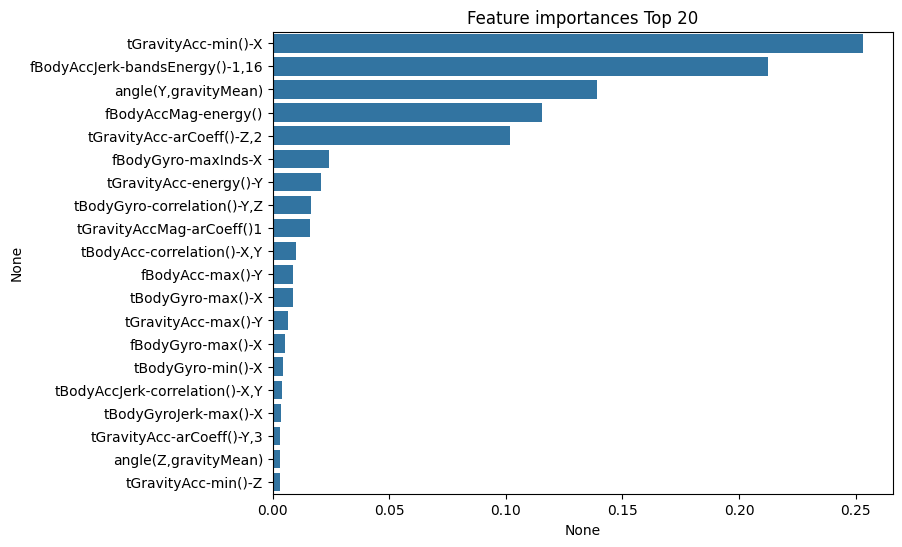

In [ ]:
import seaborn as sns

ftr_importances_values = best_df_clf.feature_importances_
# Top 중요도로 정렬을 쉽게 하고, 시본(Seaborn)의 막대그래프로 쉽게 표현하기 위해 Series 변환
ftr_importances = pd.Series(ftr_importances_values, index=X_train.columns)
# 중요도값 순으로 Series를 정렬
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]
plt.figure(figsize=(8,6))
plt.title('Feature importances Top 20')
sns.barplot(x=ftr_top20, y=ftr_top20.index)
plt.show()